In [32]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

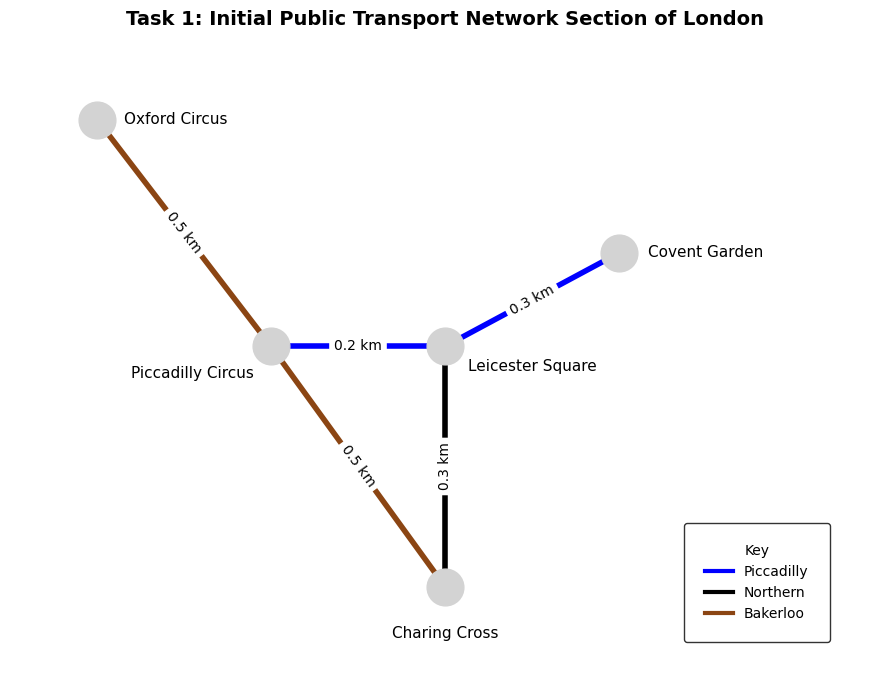

In [33]:
G1 = nx.Graph()

edges_t1 = [
    ('Oxford Circus', 'Piccadilly Circus', 0.5, 'saddlebrown'),
    ('Piccadilly Circus', 'Charing Cross', 0.5, 'saddlebrown'),
    ('Charing Cross', 'Leicester Square', 0.3, 'black'),
    ('Piccadilly Circus', 'Leicester Square', 0.2, 'blue'),
    ('Leicester Square', 'Covent Garden', 0.3, 'blue')
]

for u, v, w, c in edges_t1:
    G1.add_edge(u, v, weight=w, color=c)

pos_t1 = {
    'Oxford Circus': (1.0, 4.0),
    'Piccadilly Circus': (2.0, 2.3),
    'Charing Cross': (3.0, 0.5),
    'Leicester Square': (3.0, 2.3),
    'Covent Garden': (4.0, 3.0)
}

plt.figure(figsize=(9, 7))
colors1 = [G1[u][v]['color'] for u, v in G1.edges()]

nx.draw_networkx_nodes(G1, pos_t1, node_color='lightgray', node_size=700)
nx.draw_networkx_edges(G1, pos_t1, edge_color=colors1, width=4)

label_offsets = {
    'Oxford Circus': (1.45, 4.0),
    'Piccadilly Circus': (1.55, 2.1),
    'Charing Cross': (3.0, 0.15),
    'Leicester Square': (3.5, 2.15),
    'Covent Garden': (4.5, 3.0)
}
nx.draw_networkx_labels(G1, label_offsets, font_size=11)

edge_labels1 = nx.get_edge_attributes(G1, 'weight')
nx.draw_networkx_edge_labels(G1, pos_t1, edge_labels={k: f"{v} km" for k, v in edge_labels1.items()}, font_size=10)

for label, color in [('Piccadilly', 'blue'), ('Northern', 'black'), ('Bakerloo', 'saddlebrown')]:
    plt.plot([], [], color=color, label=label, linewidth=3)
    
plt.legend(title="Key", loc='lower right', bbox_to_anchor=(0.95, 0.05), borderpad=1.5, edgecolor='black', fontsize=10)

plt.title("Task 1: Initial Public Transport Network Section of London", fontsize=14, fontweight='bold', pad=20)
plt.xlim(0.5, 5.5)
plt.ylim(-0.2, 4.5)
plt.axis('off')
plt.tight_layout()
plt.show()

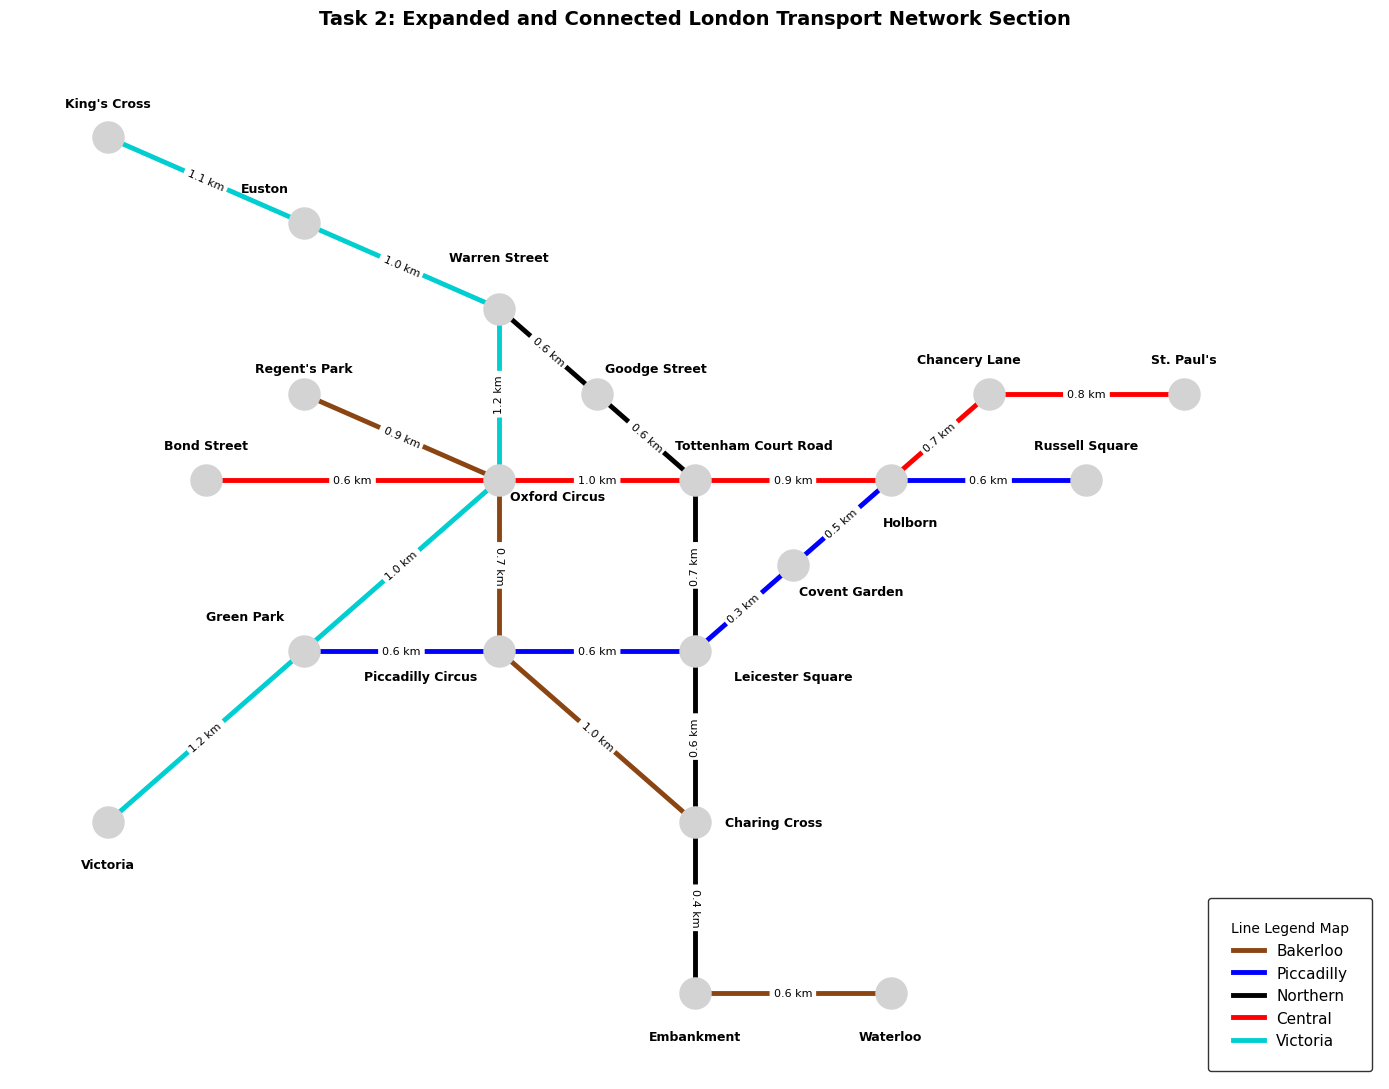

In [34]:
network_data = [
    ('Bakerloo', 'saddlebrown', [('Regent\'s Park', 0.9), ('Oxford Circus', 0.7), ('Piccadilly Circus', 1.0), ('Charing Cross', 0.4), ('Embankment', 0.6), ('Waterloo', 0.0)]),
    ('Piccadilly', 'blue', [('Green Park', 0.6), ('Piccadilly Circus', 0.6), ('Leicester Square', 0.3), ('Covent Garden', 0.5), ('Holborn', 0.6), ('Russell Square', 0.0)]),
    ('Northern', 'black', [('Warren Street', 0.6), ('Goodge Street', 0.6), ('Tottenham Court Road', 0.7), ('Leicester Square', 0.6), ('Charing Cross', 0.4), ('Embankment', 0.0)]),
    ('Central', 'red', [('Bond Street', 0.6), ('Oxford Circus', 1.0), ('Tottenham Court Road', 0.9), ('Holborn', 0.7), ('Chancery Lane', 0.8), ('St. Paul\'s', 0.0)]),
    ('Victoria', 'darkturquoise', [('Victoria', 1.2), ('Green Park', 1.0), ('Oxford Circus', 1.2), ('Warren Street', 1.0), ('Euston', 1.1), ('King\'s Cross', 0.0)])
]

G2 = nx.Graph()
for line, color, stations in network_data:
    for i in range(len(stations) - 1):
        G2.add_edge(stations[i][0], stations[i+1][0], weight=stations[i][1], color=color)

pos_t2 = {
    'Oxford Circus': (3.0, 4.0), 'Piccadilly Circus': (3.0, 3.0), 
    'Leicester Square': (4.0, 3.0), 'Charing Cross': (4.0, 2.0),
    'Tottenham Court Road': (4.0, 4.0), 'Holborn': (5.0, 4.0),
    'Warren Street': (3.0, 5.0), 'Green Park': (2.0, 3.0), 'Embankment': (4.0, 1.0),
    'Regent\'s Park': (2.0, 4.5), 'Waterloo': (5.0, 1.0),
    'Covent Garden': (4.5, 3.5), 'Russell Square': (6.0, 4.0),
    'Goodge Street': (3.5, 4.5), 'Bond Street': (1.5, 4.0), 
    'Chancery Lane': (5.5, 4.5), 'St. Paul\'s': (6.5, 4.5),
    'Victoria': (1.0, 2.0), 'Euston': (2.0, 5.5), 'King\'s Cross': (1.0, 6.0)
}

label_offsets_t2 = {
    'Oxford Circus': (3.3, 3.9), 'Piccadilly Circus': (2.6, 2.85), 
    'Leicester Square': (4.5, 2.85), 'Charing Cross': (4.4, 2.0),
    'Tottenham Court Road': (4.3, 4.2), 'Holborn': (5.1, 3.75),
    'Warren Street': (3.0, 5.3), 'Green Park': (1.7, 3.2), 
    'Embankment': (4.0, 0.75), 'Regent\'s Park': (2.0, 4.65), 
    'Waterloo': (5.0, 0.75), 'Covent Garden': (4.8, 3.35), 
    'Russell Square': (6.0, 4.2), 'Goodge Street': (3.8, 4.65),
    'Bond Street': (1.5, 4.2), 'Chancery Lane': (5.4, 4.7), 
    'St. Paul\'s': (6.5, 4.7), 'Victoria': (1.0, 1.75), 
    'Euston': (1.8, 5.7), 'King\'s Cross': (1.0, 6.2)
}

plt.figure(figsize=(14, 11))
colors2 = [G2[u][v]['color'] for u, v in G2.edges()]

nx.draw_networkx_nodes(G2, pos_t2, node_color='lightgray', node_size=500)
nx.draw_networkx_edges(G2, pos_t2, edge_color=colors2, width=3.5)

nx.draw_networkx_labels(G2, label_offsets_t2, font_size=9, font_weight='bold')

edge_labels2 = nx.get_edge_attributes(G2, 'weight')
nx.draw_networkx_edge_labels(G2, pos_t2, edge_labels={k: f"{v} km" for k, v in edge_labels2.items() if v > 0}, font_size=8)

for line, color, _ in network_data:
    plt.plot([], [], color=color, label=line, linewidth=3.5)
plt.legend(title="Line Legend Map", loc='lower right', borderpad=1.5, edgecolor='black', fontsize=11)

plt.title("Task 2: Expanded and Connected London Transport Network Section", fontsize=14, fontweight='bold', pad=20)
plt.xlim(0.5, 7.5)
plt.ylim(0.5, 6.5)
plt.axis('off')
plt.tight_layout()
plt.show()

In [35]:
distances = [d['weight'] for u, v, d in G2.edges(data=True) if d['weight'] > 0]

df_metrics = pd.DataFrame({
    'Network Metric': [
        'Total length of the transport network', 
        'The average distance between the stations', 
        'The standard deviation of the distances'
    ],
    'Value (km)': [
        round(np.sum(distances), 2), 
        round(np.mean(distances), 2), 
        round(np.std(distances), 2)
    ]
})

print("=== TASK 3: OBTAINED NUMERICAL RESULTS ===")
print(df_metrics.to_string(index=False))

=== TASK 3: OBTAINED NUMERICAL RESULTS ===
                           Network Metric  Value (km)
    Total length of the transport network       18.20
The average distance between the stations        0.76
  The standard deviation of the distances        0.24
